<a href="https://colab.research.google.com/github/DestonSJU/AgenticAI/blob/main/HW4/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# //*** Deston Willis
# //*** Generative/Agentic AI
# //*** 3/17/26
# //*** Assignment 4: The purpose of this assignment is to test different retrival methods and compare the chunks that they receive as well as the responses that the model creates from them

## Documents Used:
For my documents, I decided to focus on documents pertaining to basketball and the NBA. These documents consistent of different aspects of these topics such as the history and rules of basketball as well some ways that it has changed.

In [20]:
!pip install -qU langchain-core langchain-community langchain-google-genai langchain-classic
!pip install -qU faiss-cpu pypdf rank_bm25 flashrank

# Standard imports for environment management
import os
from google.colab import userdata
os.environ["TQDM_DISABLE"] = "1"

# API Key from Colab Secrets
os.environ["GOOGLE_API_KEY"] = userdata.get('DefaultGeminiProject')


In [21]:
# Mount google drive to use files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Trial A:


### Chunks:
--- Testing: Factual Search Test ---

Query: Who created basketball and when did they create it?

Rank 1: [/content/20588_Brief History of Basketball week 4.pdf] Brief History of Basketball: Basketball was invented by Dr. James Naismith, a Canadian  physical education instructor, in December 1891 in Springfield, Massachusetts, USA. He  created the game as a wa...

Rank 2: [/content/03-more_coaching.pdf] Basketball History    Dr. James Naismith invented the game in 1891 in Springfield, Massachusetts at  Springfield College.  He was a Presbyterian minister (but never preached)… and a doctor  (but never...

Rank 3: [/content/Basketball Cornell Notes.pdf] History Dr. James Naismith, a Canadian Physical Education Instructor,  invented the  game of basketball in 1891. He was born in Almonte, Ontario and educated at McGill Uni- versity and Presbyterian Co...

--- Testing: Conceptual Search Test ---

Query: How has basketball changed over time?

Rank 1: [/content/NBA_Bonus_Timeline.pdf] HOW THE NBA  CHANGED  THE GAME The NBA Story...

Rank 2: [/content/03-more_coaching.pdf] ball up the court and speed up the game.  Many teams held the ball for very long periods  of time, and the scores were very low.    The game has come a long way.  To quote Bob Broeg, “Th e roundball, ...

Rank 3: [/content/03-more_coaching.pdf] had not yet been invented!  Dribbling and ball handling was not as good, with a lopsided  ball....

--- Testing: Technical Search Test ---

Query: What are the rules regarding fouls in basketball?

Rank 1: [/content/20588_Brief History of Basketball week 4.pdf] Rules and Regulations: Basketball has a set of rules and regulations that govern  gameplay. Some key rules include:...

Rank 2: [/content/20588_Brief History of Basketball week 4.pdf] 3. Fouls: Players are not allowed to make physical contact with opponents that hinders their  movement or affects their ability to play. Fouls result in free throws or possession of the  ball.  4. Vio...

Rank 3: [/content/20588_Brief History of Basketball week 4.pdf] 5. Time: The game is divided into quarters, with breaks between each quarter and at halftime.  Overtime periods are played if the score is tied at the end of regulation time.  Officials in Basketball:...

### Results:
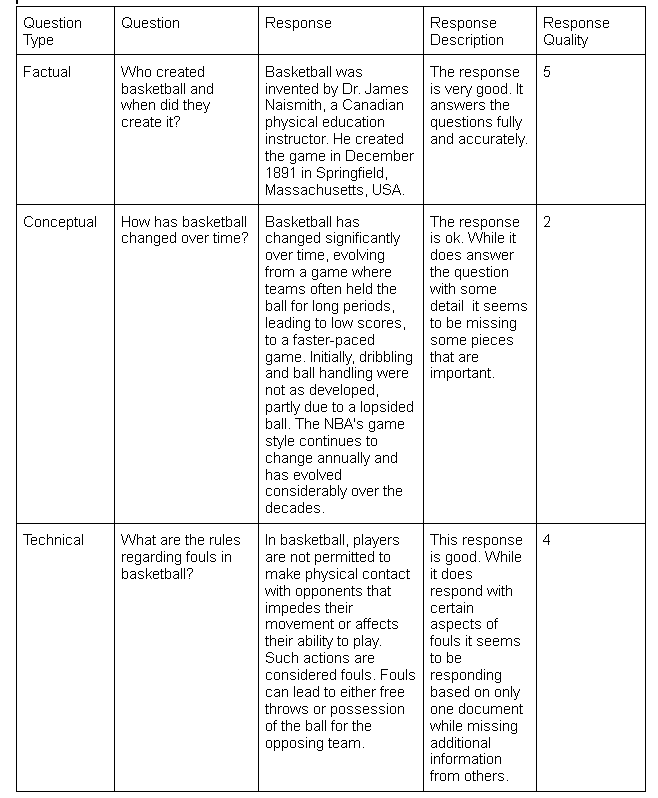

In [22]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os

# Files used
file_names = [
    "drive/MyDrive/Agentic_AI_Homework_4/03-more_coaching.pdf",
    "drive/MyDrive/Agentic_AI_Homework_4/20588_Brief History of Basketball week 4.pdf",
    "drive/MyDrive/Agentic_AI_Homework_4/Basketball Cornell Notes.pdf",
    "drive/MyDrive/Agentic_AI_Homework_4/FE005052.pdf",
    "drive/MyDrive/Agentic_AI_Homework_4/NBA_Bonus_Timeline.pdf",
    "drive/MyDrive/Agentic_AI_Homework_4/The-National-Basketball-Association.pdf"
]

all_docs = []

# Loop through each file, load its content, and split it into chunks
for file in file_names:
    if os.path.exists(file):
        print(f"Processing {file}...")
        loader = PyPDFLoader(file)

        # Recursive splitter attempts to keep paragraphs and sentences together
        # chunk_size is total characters; overlap keeps context across boundaries
        splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=10)
        chunks = loader.load_and_split(splitter)

        all_docs.extend(chunks)
    else:
        print(f"Warning: '{file}' not found in the sidebar. Please upload it.")

if all_docs:
    print(f"\nSuccess! Total text chunks created: {len(all_docs)}")

Processing drive/MyDrive/Agentic_AI_Homework_4/03-more_coaching.pdf...
Processing drive/MyDrive/Agentic_AI_Homework_4/20588_Brief History of Basketball week 4.pdf...
Processing drive/MyDrive/Agentic_AI_Homework_4/Basketball Cornell Notes.pdf...
Processing drive/MyDrive/Agentic_AI_Homework_4/FE005052.pdf...
Processing drive/MyDrive/Agentic_AI_Homework_4/NBA_Bonus_Timeline.pdf...
Processing drive/MyDrive/Agentic_AI_Homework_4/The-National-Basketball-Association.pdf...

Success! Total text chunks created: 177


In [ ]:
import time
from tenacity import retry, stop_after_attempt, wait_random_exponential, retry_if_exception_type
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

# Initialize Gemini Embeddings (2026 Stable Model)
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    task_type="retrieval_document"
)



# Define the Retry-Safe Embedding Wrapper
# This function will wait and retry automatically if we get a 429 error.
@retry(
    wait=wait_random_exponential(min=1, max=60),
    stop=stop_after_attempt(10),
    retry=retry_if_exception_type(Exception) # Catch the GoogleGenerativeAIError
)
def embed_with_retry(vector_store, batch):
    if vector_store is None:
        return FAISS.from_documents(batch, embeddings)
    else:
        vector_store.add_documents(batch)
        return vector_store



# Process with Batching and Retries
batch_size = 15 # Smaller batches help prevent hitting the limit too fast
vectorstore = None

print(f"Embedding {len(all_docs)} chunks with rate-limit protection...")
for i in range(0, len(all_docs), batch_size):
    batch = all_docs[i : i + batch_size]
    try:
        vectorstore = embed_with_retry(vectorstore, batch)
        print(f" Processed {i + len(batch)}/{len(all_docs)}...")
    except Exception as e:
        print(f" Failed after retries: {e}")
        break
    time.sleep(3) # A steady 3-second heartbeat to keep the API happy




# Finalize Retrievers
# Only Naive Similarity Retriver is used in this case
if vectorstore:
    vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
    bm25_retriever = BM25Retriever.from_documents(all_docs)
    bm25_retriever.k = 3

    hybrid_retriever = EnsembleRetriever(
        retrievers=[vector_retriever, bm25_retriever],
        weights=[1.0, 0.0]
    )
    print("\n Hybrid Retriever is ready!")



Embedding 177 chunks with rate-limit protection...
 Processed 15/177...
 Processed 30/177...
 Processed 45/177...
 Processed 60/177...
 Processed 75/177...
 Processed 90/177...
 Processed 105/177...
 Processed 120/177...
 Processed 135/177...
 Processed 150/177...
 Processed 165/177...
 Processed 177/177...

 Hybrid Retriever is ready!


In [ ]:
# Test Queries
factual_query = "Who created basketball and when did they create it?"
conceptual_query = "How has basketball changed over time?"
technical_query = "What are the rules regarding fouls in basketball?"


def test_retriever(query, name):
    print(f"\n--- Testing: {name} ---")
    print(f"Query: {query}")
    docs = hybrid_retriever.invoke(query)

    for i, doc in enumerate(docs[:3]): # Show top 3 results
        source = doc.metadata.get('source', 'Unknown')
        # We truncate the content for readability
        content = doc.page_content[:200].replace('\n', ' ')
        print(f"Rank {i+1}: [{source}] {content}...")



# Run the tests
test_retriever(factual_query, "Factual Search Test")
test_retriever(conceptual_query, "Conceptual Search Test")
test_retriever(technical_query, "Technical Search Test")




--- Testing: Factual Search Test ---
Query: Who created basketball and when did they create it?
Rank 1: [/content/20588_Brief History of Basketball week 4.pdf] Brief History of Basketball: Basketball was invented by Dr. James Naismith, a Canadian  physical education instructor, in December 1891 in Springfield, Massachusetts, USA. He  created the game as a wa...
Rank 2: [/content/03-more_coaching.pdf] Basketball History    Dr. James Naismith invented the game in 1891 in Springfield, Massachusetts at  Springfield College.  He was a Presbyterian minister (but never preached)… and a doctor  (but never...
Rank 3: [/content/Basketball Cornell Notes.pdf] History Dr. James Naismith, a Canadian Physical Education Instructor,  invented the  game of basketball in 1891. He was born in Almonte, Ontario and educated at McGill Uni- versity and Presbyterian Co...

--- Testing: Conceptual Search Test ---
Query: How has basketball changed over time?
Rank 1: [/content/NBA_Bonus_Timeline.pdf] HOW THE NBA

In [ ]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

# Hub import for modular LangChain
try:
    from langchain_classic import hub
except ImportError:
    import langchainhub as hub


# Gemini 2.5 Flash is the 'sweet spot' for speed and availability.
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.0
)



# Attach Rate-Limit Protection
llm_with_retry = llm.with_retry(
    stop_after_attempt=5,
    wait_exponential_jitter=True
)



# Pull the standard RAG prompt
prompt = hub.pull("rlm/rag-prompt")



# THE LCEL PIPELINE (The "Pipe" Syntax)
rag_chain = (
    RunnableParallel({
        "context": hybrid_retriever,
        "question": RunnablePassthrough()
    })
    | prompt
    | llm_with_retry
    | StrOutputParser()
)

In [ ]:
# Factual Question
factual_query = "Who created basketball and when did they create it?"

try:
    answer = rag_chain.invoke(factual_query)
    print(f"QUESTION: {factual_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f" Chain failed: {e}")



QUESTION: Who created basketball and when did they create it?

ANSWER:
Basketball was invented by Dr. James Naismith, a Canadian physical education instructor. He created the game in December 1891 in Springfield, Massachusetts, USA.


In [ ]:
# Conceptual Question
conceptual_query = "How has basketball changed over time?"

try:
    # This will use the same Gemini 2.5 Flash + Hybrid Retriever + Re-ranker
    answer = rag_chain.invoke(conceptual_query)
    print(f"QUESTION: {conceptual_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f"Conceptual test failed: {e}")



QUESTION: How has basketball changed over time?

ANSWER:
Basketball has changed significantly over time, evolving from a game where teams often held the ball for long periods, leading to low scores, to a faster-paced game. Initially, dribbling and ball handling were not as developed, partly due to a lopsided ball. The NBA's game style continues to change annually and has evolved considerably over the decades.


In [ ]:
# Technical Question
technical_query = "What are the rules regarding fouls in basketball?"

try:
    # This will use the same Gemini 2.5 Flash + Hybrid Retriever + Re-ranker
    answer = rag_chain.invoke(technical_query)
    print(f"QUESTION: {technical_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f"Conceptual test failed: {e}")


QUESTION: What are the rules regarding fouls in basketball?

ANSWER:
In basketball, players are not permitted to make physical contact with opponents that impedes their movement or affects their ability to play. Such actions are considered fouls. Fouls can lead to either free throws or possession of the ball for the opposing team.


## Trial B:

### Chunks:
--- Testing: Factual Search Test ---

Query: Who created basketball and when did they create it?

Rank 1: [/content/Basketball Cornell Notes.pdf] History Dr. James Naismith, a Canadian Physical Education Instructor,  invented the  game of basketball in 1891. He was born in Almonte, Ontario and educated at McGill Uni- versity and Presbyterian Co...

Rank 2: [/content/03-more_coaching.pdf] Creatine does not replace conditioning, weight training, practice, and hard work in achieving  athletic success. Any benefits are probably minimal, and could be achieved by weight training  and practi...

Rank 3: [/content/03-more_coaching.pdf] Also, when using competitive drills (wher e the losing team has to run a few sprints),  instead of just running sprints, always have them take a ball with them and speed dribble  back and forth, so th...

--- Testing: Conceptual Search Test ---

Query: How has basketball changed over time?

Rank 1: [/content/FE005052.pdf] spread over five to six months or two to five games  per week. In addition, players participate in a month- long preseason of games and practices [1]. One of  the most fascinating elements of NBA game...

Rank 2: [/content/03-more_coaching.pdf] coaches talking to each other and not have any idea of what they are talking about! This  is true in almost any subject. Studying to become a doctor, you first have to know the  names of all the parts...

Rank 3: [/content/Basketball Cornell Notes.pdf] joyed sport, with leagues for all ages and abilities. Currently more than 30 million Ameri- Answer the questions.   1. Who invented the game of  basketball and list two  changes to the original   thir...

--- Testing: Technical Search Test ---

Query: What are the rules regarding fouls in basketball?

Rank 1: [/content/20588_Brief History of Basketball week 4.pdf] 5. Time: The game is divided into quarters, with breaks between each quarter and at halftime.  Overtime periods are played if the score is tied at the end of regulation time.  Officials in Basketball:...

Rank 2: [/content/FE005052.pdf] ‘ ’ refers to p-value less than 1 In the right column, there are three numbers. The left one  refers to the Coefficient value. The middle number in the  parenthesis is the t value - the size of the di...

Rank 3: [/content/20588_Brief History of Basketball week 4.pdf] Rules and Regulations: Basketball has a set of rules and regulations that govern  gameplay. Some key rules include:...


### Results:
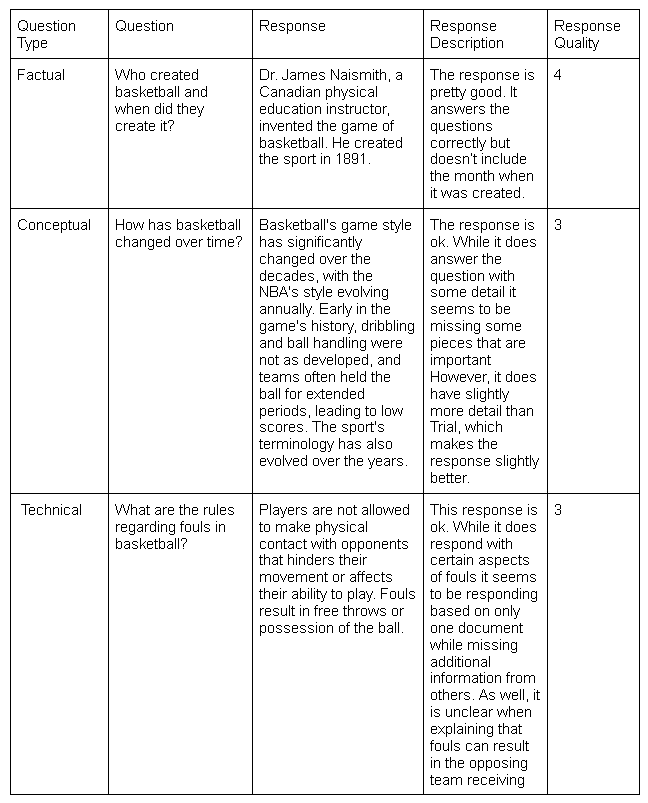

In [ ]:
import time
from tenacity import retry, stop_after_attempt, wait_random_exponential, retry_if_exception_type
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

# Initialize Gemini Embeddings (2026 Stable Model)
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    task_type="retrieval_document"
)



# Define the Retry-Safe Embedding Wrapper
# This function will wait and retry automatically if we get a 429 error.
@retry(
    wait=wait_random_exponential(min=1, max=60),
    stop=stop_after_attempt(10),
    retry=retry_if_exception_type(Exception) # Catch the GoogleGenerativeAIError
)
def embed_with_retry(vector_store, batch):
    if vector_store is None:
        return FAISS.from_documents(batch, embeddings)
    else:
        vector_store.add_documents(batch)
        return vector_store



# Process with Batching and Retries
batch_size = 15 # Smaller batches help prevent hitting the limit too fast
vectorstore = None

print(f"Embedding {len(all_docs)} chunks with rate-limit protection...")
for i in range(0, len(all_docs), batch_size):
    batch = all_docs[i : i + batch_size]
    try:
        vectorstore = embed_with_retry(vectorstore, batch)
        print(f" Processed {i + len(batch)}/{len(all_docs)}...")
    except Exception as e:
        print(f" Failed after retries: {e}")
        break
    time.sleep(3) # A steady 3-second heartbeat to keep the API happy




# Finalize Retrievers
# In this case only MMR Retriver is used
if vectorstore:
    vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
    bm25_retriever = BM25Retriever.from_documents(all_docs)
    bm25_retriever.k = 3

    hybrid_retriever = EnsembleRetriever(
        retrievers=[vector_retriever, bm25_retriever],
        weights=[0.0, 1.0]
    )
    print("\n Hybrid Retriever is ready!")



Embedding 177 chunks with rate-limit protection...
 Processed 15/177...
 Processed 30/177...
 Processed 45/177...
 Processed 60/177...
 Processed 75/177...
 Processed 90/177...
 Processed 105/177...
 Processed 120/177...
 Processed 135/177...
 Processed 150/177...
 Processed 165/177...
 Processed 177/177...

 Hybrid Retriever is ready!


In [ ]:
# Test Queries
factual_query = "Who created basketball and when did they create it?"
conceptual_query = "How has basketball changed over time?"
technical_query = "What are the rules regarding fouls in basketball?"


def test_retriever(query, name):
    print(f"\n--- Testing: {name} ---")
    print(f"Query: {query}")
    docs = hybrid_retriever.invoke(query)

    for i, doc in enumerate(docs[:3]): # Show top 3 results
        source = doc.metadata.get('source', 'Unknown')
        # We truncate the content for readability
        content = doc.page_content[:200].replace('\n', ' ')
        print(f"Rank {i+1}: [{source}] {content}...")



# Run the tests
test_retriever(factual_query, "Factual Search Test")
test_retriever(conceptual_query, "Conceptual Search Test")
test_retriever(technical_query, "Technical Search Test")




--- Testing: Factual Search Test ---
Query: Who created basketball and when did they create it?
Rank 1: [/content/Basketball Cornell Notes.pdf] History Dr. James Naismith, a Canadian Physical Education Instructor,  invented the  game of basketball in 1891. He was born in Almonte, Ontario and educated at McGill Uni- versity and Presbyterian Co...
Rank 2: [/content/03-more_coaching.pdf] Creatine does not replace conditioning, weight training, practice, and hard work in achieving  athletic success. Any benefits are probably minimal, and could be achieved by weight training  and practi...
Rank 3: [/content/03-more_coaching.pdf] Also, when using competitive drills (wher e the losing team has to run a few sprints),  instead of just running sprints, always have them take a ball with them and speed dribble  back and forth, so th...

--- Testing: Conceptual Search Test ---
Query: How has basketball changed over time?
Rank 1: [/content/FE005052.pdf] spread over five to six months or two to five

In [ ]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

# Hub import for modular LangChain
try:
    from langchain_classic import hub
except ImportError:
    import langchainhub as hub


# Gemini 2.5 Flash is the 'sweet spot' for speed and availability.
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.0
)



# Attach Rate-Limit Protection
llm_with_retry = llm.with_retry(
    stop_after_attempt=5,
    wait_exponential_jitter=True
)



# Pull the standard RAG prompt
prompt = hub.pull("rlm/rag-prompt")



# THE LCEL PIPELINE (The "Pipe" Syntax)
rag_chain = (
    RunnableParallel({
        "context": hybrid_retriever,
        "question": RunnablePassthrough()
    })
    | prompt
    | llm_with_retry
    | StrOutputParser()
)

In [ ]:
# Factual Question
factual_query = "Who created basketball and when did they create it?"

try:
    answer = rag_chain.invoke(factual_query)
    print(f"QUESTION: {factual_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f" Chain failed: {e}")



QUESTION: Who created basketball and when did they create it?

ANSWER:
Dr. James Naismith, a Canadian physical education instructor, invented the game of basketball. He created the sport in 1891.


In [ ]:
# Conceptual Question
conceptual_query = "How has basketball changed over time?"

try:
    # This will use the same Gemini 2.5 Flash + Hybrid Retriever + Re-ranker
    answer = rag_chain.invoke(conceptual_query)
    print(f"QUESTION: {conceptual_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f"Conceptual test failed: {e}")



QUESTION: How has basketball changed over time?

ANSWER:
Basketball's game style has significantly changed over the decades, with the NBA's style evolving annually. Early in the game's history, dribbling and ball handling were not as developed, and teams often held the ball for extended periods, leading to low scores. The sport's terminology has also evolved over the years.


In [ ]:
# Technical Question
technical_query = "What are the rules regarding fouls in basketball?"

try:
    # This will use the same Gemini 2.5 Flash + Hybrid Retriever + Re-ranker
    answer = rag_chain.invoke(technical_query)
    print(f"QUESTION: {technical_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f"Conceptual test failed: {e}")


QUESTION: What are the rules regarding fouls in basketball?

ANSWER:
Players are not allowed to make physical contact with opponents that hinders their movement or affects their ability to play. Fouls result in free throws or possession of the ball.


## Trial C:

### Chunks:
--- Testing: Factual Search Test ---

Query: Who created basketball and when did they create it?

Rank 1: [drive/MyDrive/Agentic_AI_Homework_4/Basketball Cornell Notes.pdf] History Dr. James Naismith, a Canadian Physical Education Instructor,  invented the  game of basketball in 1891. He was born in Almonte, Ontario and educated at McGill Uni- versity and Presbyterian Co...

Rank 2: [drive/MyDrive/Agentic_AI_Homework_4/20588_Brief History of Basketball week 4.pdf] Brief History of Basketball: Basketball was invented by Dr. James Naismith, a Canadian  physical education instructor, in December 1891 in Springfield, Massachusetts, USA. He  created the game as a wa...

Rank 3: [drive/MyDrive/Agentic_AI_Homework_4/03-more_coaching.pdf] Basketball History    Dr. James Naismith invented the game in 1891 in Springfield, Massachusetts at  Springfield College.  He was a Presbyterian minister (but never preached)… and a doctor  (but never...


--- Testing: Conceptual Search Test ---

Query: How has basketball changed over time?

Rank 1: [drive/MyDrive/Agentic_AI_Homework_4/NBA_Bonus_Timeline.pdf] HOW THE NBA  CHANGED  THE GAME The NBA Story...

Rank 2: [drive/MyDrive/Agentic_AI_Homework_4/FE005052.pdf] spread over five to six months or two to five games  per week. In addition, players participate in a month- long preseason of games and practices [1]. One of  the most fascinating elements of NBA game...

Rank 3: [drive/MyDrive/Agentic_AI_Homework_4/03-more_coaching.pdf] ball up the court and speed up the game.  Many teams held the ball for very long periods  of time, and the scores were very low.    The game has come a long way.  To quote Bob Broeg, “Th e roundball, ...

--- Testing: Technical Search Test ---

Query: What are the rules regarding fouls in basketball?

Rank 1: [drive/MyDrive/Agentic_AI_Homework_4/20588_Brief History of Basketball week 4.pdf] Rules and Regulations: Basketball has a set of rules and regulations that govern  gameplay. Some key rules include:...

Rank 2: [drive/MyDrive/Agentic_AI_Homework_4/20588_Brief History of Basketball week 4.pdf] 5. Time: The game is divided into quarters, with breaks between each quarter and at halftime.  Overtime periods are played if the score is tied at the end of regulation time.  Officials in Basketball:...

Rank 3: [drive/MyDrive/Agentic_AI_Homework_4/20588_Brief History of Basketball week 4.pdf] 3. Fouls: Players are not allowed to make physical contact with opponents that hinders their  movement or affects their ability to play. Fouls result in free throws or possession of the  ball.  4. Vio...


### Results:
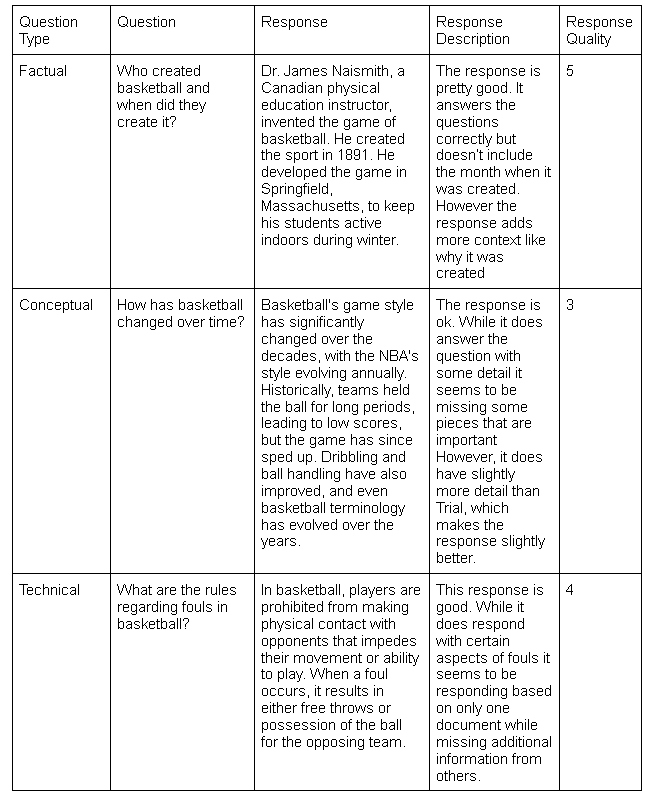

In [14]:
import time
from tenacity import retry, stop_after_attempt, wait_random_exponential, retry_if_exception_type
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

# Initialize Gemini Embeddings (2026 Stable Model)
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    task_type="retrieval_document"
)



# Define the Retry-Safe Embedding Wrapper
# This function will wait and retry automatically if we get a 429 error.
@retry(
    wait=wait_random_exponential(min=1, max=60),
    stop=stop_after_attempt(10),
    retry=retry_if_exception_type(Exception) # Catch the GoogleGenerativeAIError
)
def embed_with_retry(vector_store, batch):
    if vector_store is None:
        return FAISS.from_documents(batch, embeddings)
    else:
        vector_store.add_documents(batch)
        return vector_store



# Process with Batching and Retries
batch_size = 15 # Smaller batches help prevent hitting the limit too fast
vectorstore = None

print(f"Embedding {len(all_docs)} chunks with rate-limit protection...")
for i in range(0, len(all_docs), batch_size):
    batch = all_docs[i : i + batch_size]
    try:
        vectorstore = embed_with_retry(vectorstore, batch)
        print(f" Processed {i + len(batch)}/{len(all_docs)}...")
    except Exception as e:
        print(f" Failed after retries: {e}")
        break
    time.sleep(3) # A steady 3-second heartbeat to keep the API happy




# Finalize Retrievers
if vectorstore:
    vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
    bm25_retriever = BM25Retriever.from_documents(all_docs)
    bm25_retriever.k = 3

    hybrid_retriever = EnsembleRetriever(
        retrievers=[vector_retriever, bm25_retriever],
        weights=[0.5, 0.5]
    )
    print("\n Hybrid Retriever is ready!")



Embedding 177 chunks with rate-limit protection...
 Processed 15/177...
 Processed 30/177...
 Processed 45/177...
 Processed 60/177...
 Processed 75/177...
 Processed 90/177...
 Processed 105/177...
 Processed 120/177...
 Processed 135/177...
 Processed 150/177...
 Processed 165/177...
 Processed 177/177...

 Hybrid Retriever is ready!


In [15]:
# Test Queries
factual_query = "Who created basketball and when did they create it?"
conceptual_query = "How has basketball changed over time?"
technical_query = "What are the rules regarding fouls in basketball?"


def test_retriever(query, name):
    print(f"\n--- Testing: {name} ---")
    print(f"Query: {query}")
    docs = hybrid_retriever.invoke(query)

    for i, doc in enumerate(docs[:3]): # Show top 3 results
        source = doc.metadata.get('source', 'Unknown')
        # We truncate the content for readability
        content = doc.page_content[:200].replace('\n', ' ')
        print(f"Rank {i+1}: [{source}] {content}...")



# Run the tests
test_retriever(factual_query, "Factual Search Test")
test_retriever(conceptual_query, "Conceptual Search Test")
test_retriever(technical_query, "Technical Search Test")




--- Testing: Factual Search Test ---
Query: Who created basketball and when did they create it?
Rank 1: [drive/MyDrive/Agentic_AI_Homework_4/Basketball Cornell Notes.pdf] History Dr. James Naismith, a Canadian Physical Education Instructor,  invented the  game of basketball in 1891. He was born in Almonte, Ontario and educated at McGill Uni- versity and Presbyterian Co...
Rank 2: [drive/MyDrive/Agentic_AI_Homework_4/20588_Brief History of Basketball week 4.pdf] Brief History of Basketball: Basketball was invented by Dr. James Naismith, a Canadian  physical education instructor, in December 1891 in Springfield, Massachusetts, USA. He  created the game as a wa...
Rank 3: [drive/MyDrive/Agentic_AI_Homework_4/03-more_coaching.pdf] Basketball History    Dr. James Naismith invented the game in 1891 in Springfield, Massachusetts at  Springfield College.  He was a Presbyterian minister (but never preached)… and a doctor  (but never...

--- Testing: Conceptual Search Test ---
Query: How has ba

In [16]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

# Hub import for modular LangChain
try:
    from langchain_classic import hub
except ImportError:
    import langchainhub as hub


# Gemini 2.5 Flash is the 'sweet spot' for speed and availability.
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.0
)



# Attach Rate-Limit Protection
llm_with_retry = llm.with_retry(
    stop_after_attempt=5,
    wait_exponential_jitter=True
)



# Pull the standard RAG prompt
prompt = hub.pull("rlm/rag-prompt")



# THE LCEL PIPELINE (The "Pipe" Syntax)
rag_chain = (
    RunnableParallel({
        "context": hybrid_retriever,
        "question": RunnablePassthrough()
    })
    | prompt
    | llm_with_retry
    | StrOutputParser()
)

In [17]:
# Factual Question
factual_query = "Who created basketball and when did they create it?"

try:
    answer = rag_chain.invoke(factual_query)
    print(f"QUESTION: {factual_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f" Chain failed: {e}")



QUESTION: Who created basketball and when did they create it?

ANSWER:
Dr. James Naismith, a Canadian physical education instructor, invented the game of basketball. He created the sport in 1891. He developed the game in Springfield, Massachusetts, to keep his students active indoors during winter.


In [18]:
# Conceptual Question
conceptual_query = "How has basketball changed over time?"

try:
    # This will use the same Gemini 2.5 Flash + Hybrid Retriever + Re-ranker
    answer = rag_chain.invoke(conceptual_query)
    print(f"QUESTION: {conceptual_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f"Conceptual test failed: {e}")



QUESTION: How has basketball changed over time?

ANSWER:
Basketball's game style has significantly changed over the decades, with the NBA's style evolving annually. Historically, teams held the ball for long periods, leading to low scores, but the game has since sped up. Dribbling and ball handling have also improved, and even basketball terminology has evolved over the years.


In [19]:
# Technical Question
technical_query = "What are the rules regarding fouls in basketball?"

try:
    # This will use the same Gemini 2.5 Flash + Hybrid Retriever + Re-ranker
    answer = rag_chain.invoke(technical_query)
    print(f"QUESTION: {technical_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f"Conceptual test failed: {e}")


QUESTION: What are the rules regarding fouls in basketball?

ANSWER:
In basketball, players are prohibited from making physical contact with opponents that impedes their movement or ability to play. When a foul occurs, it results in either free throws or possession of the ball for the opposing team.


## Analysis:
1. Comparing Trial A to B, Trial A did have have chunks that said the same thing for some of the question. Particualy, for the Factual question, all of the chunks said very similar things. As well, while the chunks for the Technical question are different, they all come from the same document. This is not the case for Trial B, where all of the chunks for each of the questions are different. While Trial B does have some additional information compared to Trial A in its chunks for the Conceptual question, it isn't the most relevant and doesn't make too much sense without the more relevant information there to understand the full meaning. However, he response using this retrival did have slightly more information compared to the Trial A response.
2. After looking through the chunks for the 3 trials, Trial C didn't have any chunks that were not seen within Trial A or B. In the responses for Trial C, there were some instances where the response would have information that the other 2 responses didn't have. For example, for the Factual question, Trial C talked about the reasoning for why basketball was created, while the other Trials didn't have that context.
3. In my results, the LLM would tend to guess the answer if the Retrivers didn't find the neccesary information. Although the responses still had correct information for the most part, there was some information that was in the responses that were not in the chunks that were found. Retrival quality affercts Groundedness because an LLM needs the appropriate information and context in order to be grounded and give good responses. If retrival quality is good, then that means the model will be grounded since it will have the full and correct context to proprely create a response. If the retrival quality is not good, then the model will not be grounded since the retrived information might be the same or from the same source or the model might be mising information, which can result in hallucinations and worse responses overall.
4. I think that the Hybrid Search is the best retrival method for my dataset. This is because it takes the best from the other 2 retrival methods and combines them to. While Trial A had a better score for the Factual and Technical questions, Trial B had a better score for the Conceptual questions. However, Trial C had the best from both of these trials with it having the same score for the Factual and Technical questions as Trial A and the same score for the Conceptual question as Trial B. Because of this, the Hybrid Search is best since it takes the best aspects of the other retrival methods and puts them together, as well as having some information in its responses that wasn't in either of the other 2 trials.

## Extra Credit:

In [23]:
import time
from tenacity import retry, stop_after_attempt, wait_random_exponential, retry_if_exception_type
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

# Initialize Gemini Embeddings (2026 Stable Model)
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    task_type="retrieval_document"
)



# Define the Retry-Safe Embedding Wrapper
# This function will wait and retry automatically if we get a 429 error.
@retry(
    wait=wait_random_exponential(min=1, max=60),
    stop=stop_after_attempt(10),
    retry=retry_if_exception_type(Exception) # Catch the GoogleGenerativeAIError
)
def embed_with_retry(vector_store, batch):
    if vector_store is None:
        return FAISS.from_documents(batch, embeddings)
    else:
        vector_store.add_documents(batch)
        return vector_store



# Process with Batching and Retries
batch_size = 15 # Smaller batches help prevent hitting the limit too fast
vectorstore = None

print(f"Embedding {len(all_docs)} chunks with rate-limit protection...")
for i in range(0, len(all_docs), batch_size):
    batch = all_docs[i : i + batch_size]
    try:
        vectorstore = embed_with_retry(vectorstore, batch)
        print(f" Processed {i + len(batch)}/{len(all_docs)}...")
    except Exception as e:
        print(f" Failed after retries: {e}")
        break
    time.sleep(3) # A steady 3-second heartbeat to keep the API happy




# Finalize Retrievers
if vectorstore:
    vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
    bm25_retriever = BM25Retriever.from_documents(all_docs)
    bm25_retriever.k = 3

    hybrid_retriever = EnsembleRetriever(
        retrievers=[vector_retriever, bm25_retriever],
        weights=[0.5, 0.5]
    )
    print("\n Hybrid Retriever is ready!")



Embedding 177 chunks with rate-limit protection...
 Processed 15/177...
 Processed 30/177...
 Processed 45/177...
 Processed 60/177...
 Processed 75/177...
 Processed 90/177...
 Processed 105/177...
 Processed 120/177...
 Processed 135/177...
 Processed 150/177...
 Processed 165/177...
 Processed 177/177...

 Hybrid Retriever is ready!


In [24]:
# Test Queries
factual_query = "Who created basketball and when did they create it?"
conceptual_query = "How has basketball changed over time?"
technical_query = "What are the rules regarding fouls in basketball?"


def test_retriever(query, name):
    print(f"\n--- Testing: {name} ---")
    print(f"Query: {query}")
    docs = hybrid_retriever.invoke(query)

    for i, doc in enumerate(docs[:3]): # Show top 3 results
        source = doc.metadata.get('source', 'Unknown')
        # We truncate the content for readability
        content = doc.page_content[:200].replace('\n', ' ')
        print(f"Rank {i+1}: [{source}] {content}...")



# Run the tests
test_retriever(factual_query, "Factual Search Test")
test_retriever(conceptual_query, "Conceptual Search Test")
test_retriever(technical_query, "Technical Search Test")




--- Testing: Factual Search Test ---
Query: Who created basketball and when did they create it?
Rank 1: [drive/MyDrive/Agentic_AI_Homework_4/Basketball Cornell Notes.pdf] History Dr. James Naismith, a Canadian Physical Education Instructor,  invented the  game of basketball in 1891. He was born in Almonte, Ontario and educated at McGill Uni- versity and Presbyterian Co...
Rank 2: [drive/MyDrive/Agentic_AI_Homework_4/20588_Brief History of Basketball week 4.pdf] Brief History of Basketball: Basketball was invented by Dr. James Naismith, a Canadian  physical education instructor, in December 1891 in Springfield, Massachusetts, USA. He  created the game as a wa...
Rank 3: [drive/MyDrive/Agentic_AI_Homework_4/03-more_coaching.pdf] Basketball History    Dr. James Naismith invented the game in 1891 in Springfield, Massachusetts at  Springfield College.  He was a Presbyterian minister (but never preached)… and a doctor  (but never...

--- Testing: Conceptual Search Test ---
Query: How has ba

In [25]:
# UPDATED 2026 IMPORTS
try:
    # Most stable 2026 path for Contextual Compression
    from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
    from langchain.retrievers.document_compressors.flashrank_rerank import FlashrankRerank
except ImportError:
    # Alternative path used in some v1.x sub-versions
    from langchain_classic.retrievers import ContextualCompressionRetriever
    from langchain_community.document_compressors.flashrank_rerank import FlashrankRerank



# Initialize FlashRank (The tiny but mighty re-ranker)
# We set top_n=3 to ensure the LLM only sees the most relevant facts.
compressor = FlashrankRerank(model="ms-marco-MiniLM-L-12-v2", top_n=3)



# Create the Compression Retriever
# This wraps the Hybrid Retriever we just successfully built.
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=hybrid_retriever
)



#  Final Test of the Pipeline
query = "How has basketball changed over time?"
final_docs = compression_retriever.invoke(query)

print(f" Re-ranker initialized and tested. Retrieved {len(final_docs)} chunks.")



# Display the high-quality results
for i, doc in enumerate(final_docs):
    print(f"\nRANKED RESULT {i+1} (Source: {doc.metadata.get('source')}):")
    print(f"{doc.page_content[:450]}...")



 Re-ranker initialized and tested. Retrieved 3 chunks.

RANKED RESULT 1 (Source: drive/MyDrive/Agentic_AI_Homework_4/FE005052.pdf):
spread over five to six months or two to five games 
per week. In addition, players participate in a month-
long preseason of games and practices [1]. One of 
the most fascinating elements of NBA games is the 
unpredictability of each game, and no two games in 
NBA history were the same. However, the NBA’s 
game style changes annually and has significantly 
changed over the decades. For example, the most 
The Evolution and Future of n BA g ame 
s...

RANKED RESULT 2 (Source: drive/MyDrive/Agentic_AI_Homework_4/03-more_coaching.pdf):
ball up the court and speed up the game.  Many teams held the ball for very long periods 
of time, and the scores were very low. 
 
The game has come a long way.  To quote Bob Broeg, “Th e roundball, not the snowball, 
is the symbol of winter now, and winter has never been the same since 1891!” 
 
Basketball terminology  
 
Lik

In [26]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

# Hub import for modular LangChain
try:
    from langchain_classic import hub
except ImportError:
    import langchainhub as hub


# Gemini 2.5 Flash is the 'sweet spot' for speed and availability.
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.0
)



# Attach Rate-Limit Protection
llm_with_retry = llm.with_retry(
    stop_after_attempt=5,
    wait_exponential_jitter=True
)



# Pull the standard RAG prompt
prompt = hub.pull("rlm/rag-prompt")



# THE LCEL PIPELINE (The "Pipe" Syntax)
rag_chain = (
    RunnableParallel({
        "context": compression_retriever,
        "question": RunnablePassthrough()
    })
    | prompt
    | llm_with_retry
    | StrOutputParser()
)

In [28]:
# Conceptual Question
conceptual_query = "How has basketball changed over time?"

try:
    # This will use the same Gemini 2.5 Flash + Hybrid Retriever + Re-ranker
    answer = rag_chain.invoke(conceptual_query)
    print(f"QUESTION: {conceptual_query}")
    print(f"\nANSWER:\n{answer}")
except Exception as e:
    print(f"Conceptual test failed: {e}")



QUESTION: How has basketball changed over time?

ANSWER:
The NBA's game style changes annually and has significantly evolved over the decades. Historically, teams often held the ball for long periods, resulting in very low scores. The game has since come a long way, with efforts to speed up play.


## Extra Credit Analysis:
Since the three retrival methods stuglled the most with the Conceptual question, I decided to use it to test the Reranker. In my results, the Reranker did move some chunks further up. The more relevant ones were moved further up compared to the other trials, particualary Trial C since they both used the Hybrid Seacrh Retriver. In my case with this dataset, I don't think the imporvement from the Reranker is worth the extra latency. This is because the Reranker doesn't make a massive improvment in the end result of the model. The response is very similar when comparing the retriver without the Reranker vs with it so without a larger improvement to the model's response, I don't think the extra latency is worth it.